# Explore here

In [3]:
# Your code here
#-----------librerias---------------------
import pandas as pd 
import numpy as np 


#-----import del dataset-----------------
ruta = '/workspaces/machine-learning-python-templatePablo-Martin/data/raw/AB_NYC_2019.csv'
df = pd.read_csv(ruta)
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


## Exploración inicial del dataset

In [4]:
df.shape #48895 filas y 16 columnas

(48895, 16)

In [5]:
df.info() #existen columnas con valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

#### Conclusión del primer análisis:
- Hay 48895 registros de viviendas de AirBnb en Nueva York en 2019, que cuentan con 16 columnas de información
- Hay columnas con valores nulos: name, host_name, last_review y reviews_per_month
    - Por suerte, las columnas de nombres son irrelevantes y pueden sacarse del dataframe cuando se limpie, por lo que no preocupan para el EDA
    - Las otras 2 columnas presentan 10.000 valores nulos aprox. que deberán ser reemplazados más adelante
- A falta de futuras modificaciones, encontramos que en las columnas hay 10 características numéricas y 6 categóricas

### Limpieza de columnas irrelevantes para el EDA

In [6]:
df.columns 

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

De la lista de columnas, no interesan las siguientes:
- Columnas de IDs, tanto de la vivienda de airbnb como del host.
- Los nombres de los hosts y de las viviendas.
- Neighbourhood -> Ya existe neighbourhood_group para hacernos una idea de la ubicación general de cada vivienda. (al final conservé la segunda también pero acabé no usándola)
- Latitud y longitud son completamente irrelevantes.

In [7]:
#antes que nada reviso duplicados
df.drop("id" , axis = 1).duplicated().sum()

np.int64(0)

No hay duplicados, así que procedo con la limpieza de columnas.

In [8]:
df.drop(["id" , "host_id", "name" , "host_name" , "latitude" , "longitude"] , axis = 1 , inplace = True)
df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,NaN,NaN,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Análisis de variables univariantes
utilizando las 2 columnas con variables categóricas que he mantenido: neighourhood_group y  room_type

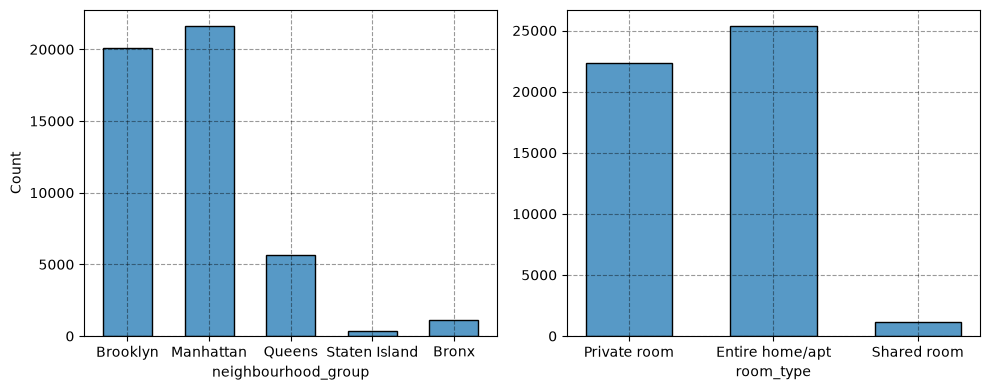

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1,2, figsize = (10, 4))


# Crear un histograma múltiple
sns.histplot(ax = axis[0], data = df, x = "neighbourhood_group", shrink= 0.6)
sns.histplot(ax = axis[1], data = df, x = "room_type",  shrink= 0.6).set(ylabel = None)
# Ajustar el layout
plt.tight_layout()
#Activar grid
#plt.grid() x2 funciona pero mejor asi
for ax in axis:
    ax.grid(True , color = "black", linestyle = "--" , alpha = 0.4)
# Mostrar el plot
plt.show()

#### Conclusiones que podemos extraer de estos gráficos:
- Manhattan y Brooklyn van a la cabeza de distritos de Nueva York donde se alquilan AirBnbs, siendo el primero ligeramente superior con más de 20.000 alquileres.
    - El resto de distritos no tienen ni la mitad de alquileres, destacando Queens que llega a los 5.000 alquileres, pero el Bronx y Staten Island apenas tienen.
- La mayoría de alquileres son de cuartos privados y casas/apartamentos enteros, donde estos últimos superan ligeramente los 25.000.
    - Casi nadie alquila habitaciones compartidas, que no llegan ni a 2.500 alquileres.

### Análisis sobre variables numéricas
Las variables numéricas relevantes para el análisis son:
- Price: el precio del alquiler.
- minimum_nights: noches mínimas requeridas de estancia para poder alquilar el lugar.
- number_of_reviews: cantidad de reviews de la vivienda en la plataforma de AirBnb.
- host_listing_accounts: cantidad de viviendas poseídas por un mismo host. 

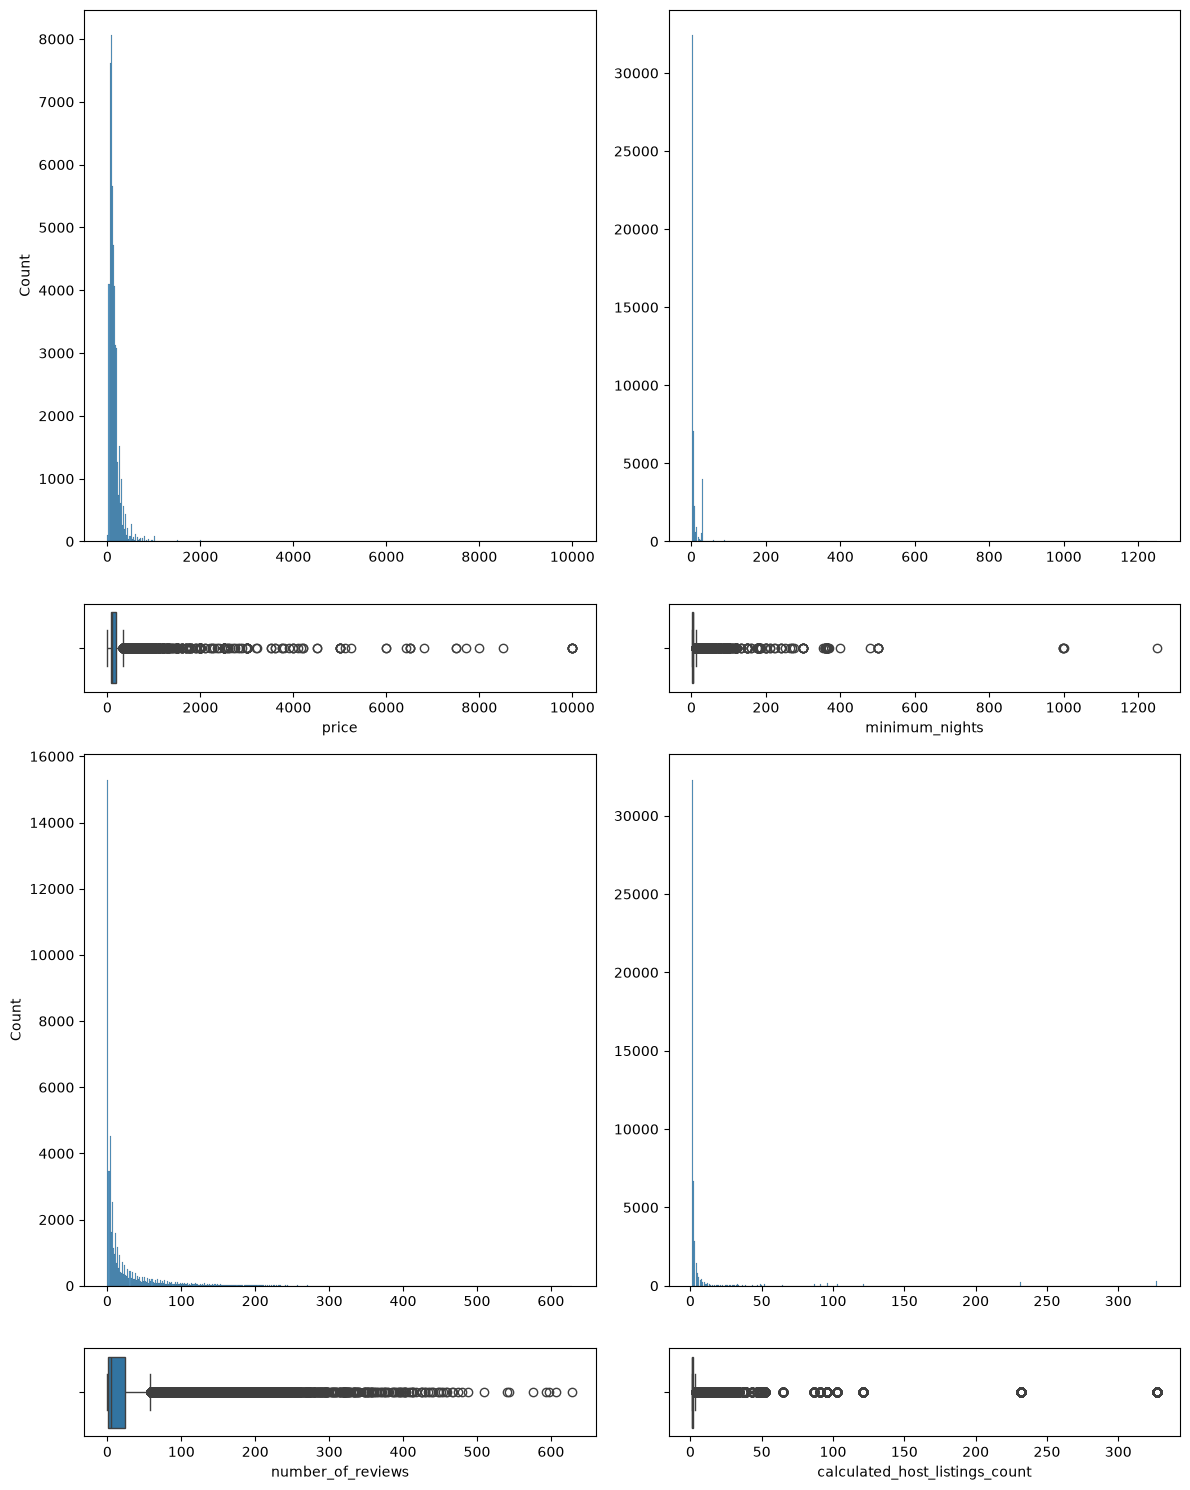

In [10]:
fig, axis = plt.subplots(4, 2, figsize = (12, 15), gridspec_kw={'height_ratios': [6, 1,6,1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "price")

sns.histplot(ax = axis[0, 1], data = df, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "minimum_nights")

sns.histplot(ax = axis[2, 0], data = df, x = "number_of_reviews").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "number_of_reviews")

sns.histplot(ax = axis[2,1], data = df, x = "calculated_host_listings_count").set(xlabel = None , ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "calculated_host_listings_count")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

#### Conclusiones 
- La mayoría de precios se sitúan entre 0 y 1.000$ , aunque hay alguna excepción.
- La grandísima mayoría de viviendas solo requieren una estancia mínima de una noche.
- Hay una gran cantidad de viviendas sin reviews, aunque esta columna tenía valores nulos y podría tratarse de un error todavía pendiente de resolver.
- Hay una gran mayoría de viviendas poseídas por los mismos host.
    - Se nota una tendencia a que muchos hosts posean más de una vivienda.

### Análisis de variables multivariante
#### Análisis numérico numérico
¿Está relacionado el precio con la cantidad mínima de noches requeridas para poder alquilar el espacio? Lo lógico es pensar que a mayor sea el requisito de noches mínimas, más cara sea la vivienda. 

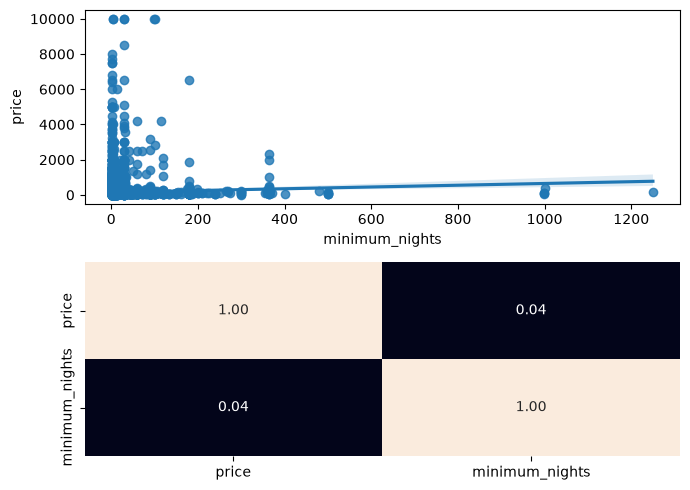

In [11]:
fig, axis = plt.subplots(2, 1, figsize = (7, 5))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0], data = df, x = "minimum_nights", y = "price")
sns.heatmap(df[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

La relación entre el precio y la cantidad de noches mínimas requeridas es prácticamente inexistente. Se puede apreciar que el precio sube ligeramente según aumenta la cantidad de noches, pero no es un indicativo lo suficientemente fuerte como para tenerlo en consideración.

Viendo que el precio no se ve afectado por el mínimo de noches, veamos si lo hace según las reviews que tiene.

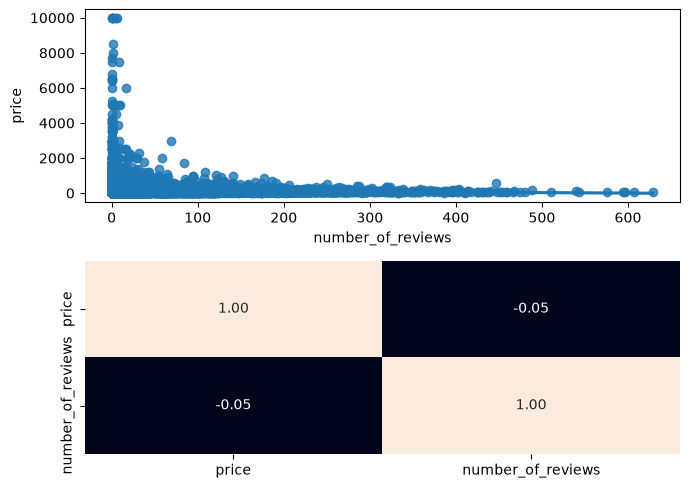

In [12]:
fig, axis = plt.subplots(2, 1, figsize = (7, 5))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0], data = df, x = "number_of_reviews", y = "price")
sns.heatmap(df[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Una vez más, no parece que haya relación entre el precio y la cantidad de reviews que posee la vivienda.

### Análisis categórico-categórico
Las variables categóricas con las que estamos trabajando son el tipo de vivienda y el distrito o barrio donde se ubican.

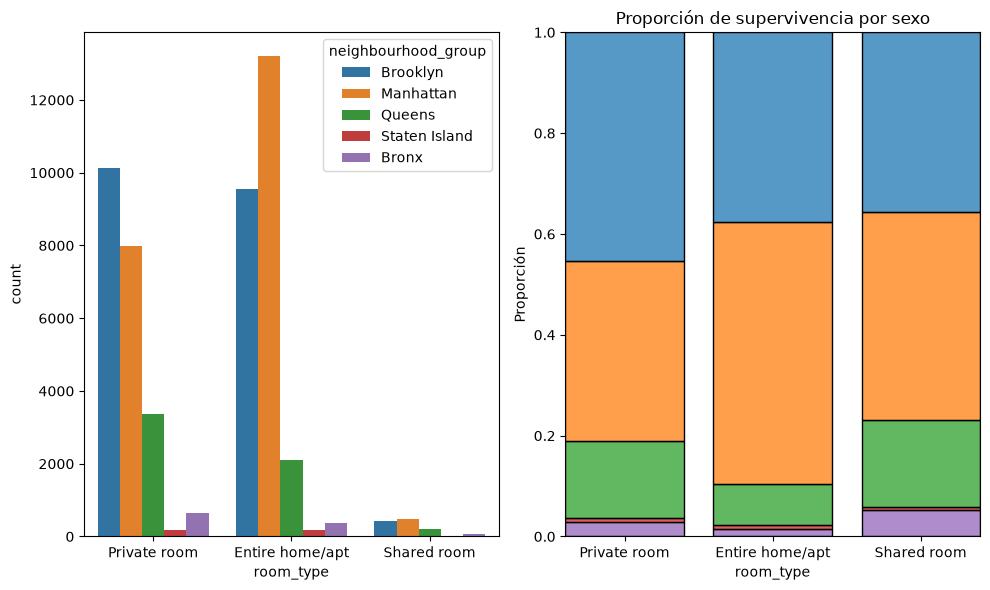

In [13]:
fig, axis = plt.subplots(1 , 2 , figsize = (10 , 6))

sns.countplot(ax = axis[0] , data = df, x = "room_type", hue = "neighbourhood_group")
sns.histplot(ax = axis[1] , data=df, x="room_type", hue="neighbourhood_group", multiple="fill", shrink=0.8 , legend= False) #no me hace falta leyenda en el grafico 2, es el mismo esquema de colores que el 1

plt.title("Proporción de supervivencia por sexo")
plt.ylabel("Proporción")
# Ajustar el layout
plt.tight_layout()


plt.show()

A partir de estos gráficos podemos ver lo siguiente:
- Brooklyn es el distrito con mayor cantidad de habitaciones privadas.
- Manhattan es el sitio donde se pueden alquilar más viviendas al completo y habitaciones compartidas.
- Como ya se apreció antes, la cantidad de habitaciones compartidas es mínima.
- Staten Island y el Bronx son los sitios con menos alquileres, mientras que Manhattan es el que va a la cabeza seguido de Brooklyn.

### Anáalisis con predictoras
Veamos los precios por distritos y por tipo de vivienda

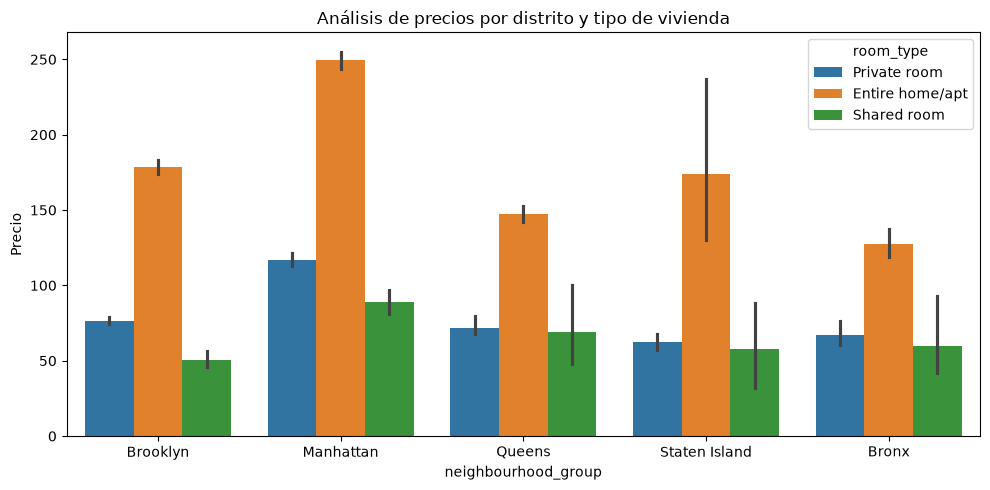

In [14]:

fig, axis = plt.subplots(figsize = (10, 5))

sns.barplot( data = df, x = "neighbourhood_group", y = "price", hue = "room_type")
plt.title("Análisis de precios por distrito y tipo de vivienda")
plt.ylabel("Precio")

plt.tight_layout()

plt.show()

- Como viene a ser lógico, el tipo de alquiler más caro es el de las viviendas completas, encontrando el mayor pico en el distrito de Manhattan.
- Inesperadamente, y con la excepción de Manhattan y Brooklyn, los precios de habitaciones privadas y compartidas son muy parejos en el resto de distritos.

### Análisis de correlaciones
Primer gráfico sin factorizar las columnas tipo string, el segundo factorizando

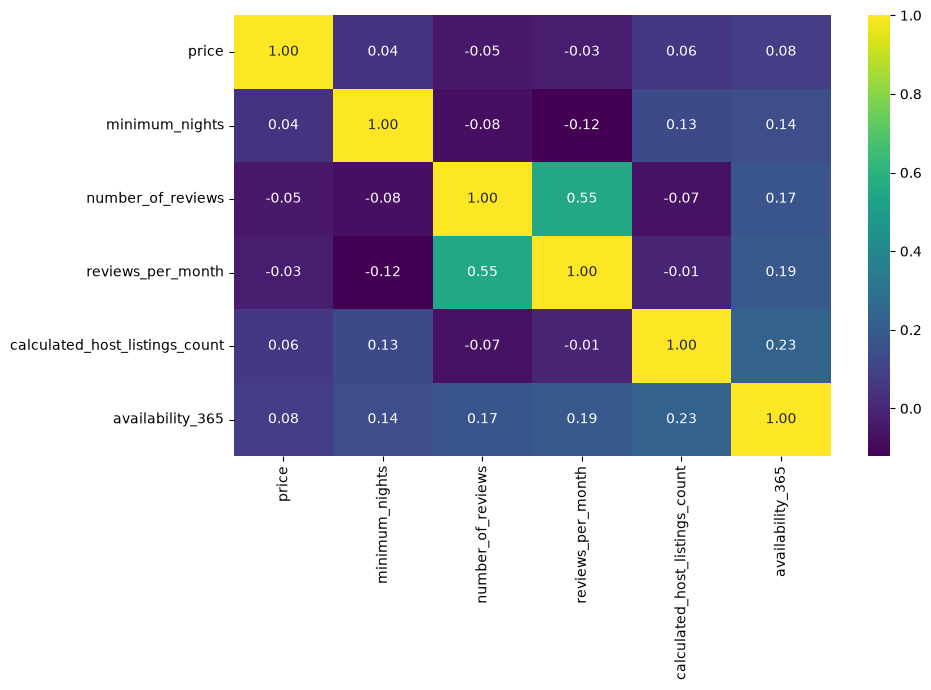

In [15]:
cols_num = ["price" , "minimum_nights" , "number_of_reviews" , "reviews_per_month" , "calculated_host_listings_count" , "availability_365"]  # lista de columnas numéricas del df

fig, ax = plt.subplots(figsize=(10,7))

sns.heatmap(df[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax) #mapa calor
plt.tight_layout()
plt.show()

- Lógicamente, las reviews totales y mensuales están estrechamente relacionadas puesto que reciben reviews con más frecuencia.
- Parece que los hosts con múltiples viviendas tienden a dejarlas más disponibles a lo largo del año.
- Los alquileres con más reviews, y que por tanto son más alquilados, tienden a tener mayor disponibilidad.
- Las viviendas que requieren múltiples noches mínimas para ser más alquiladas reciben menos reviews.
- El precio parece tener relaciones muy débiles con todas las variables, por lo que ninguna parece ser determinante a la hora de establecer el precio de las viviendas.

In [16]:
#FACTORIZACION DE COLUMNAS TIPO STRING (ROOM_TYPE Y NEIGHBOURHOOD_GROUP)
print ("neighbourhood string -> " , df.neighbourhood_group.unique())
print ("room type string -> " , df.room_type.unique())

neighbourhood string ->  <StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str
room type string ->  <StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str


In [17]:
df['neighbourhood_group_n'] = pd.factorize(df['neighbourhood_group'])[0] #factorizo neighbourhood group

df['room_type_n'] = pd.factorize(df['room_type'])[0] #factorizo room type
print( "neighbourhood -> " , df.neighbourhood_group_n.unique())
print( "room type -> " , df.room_type_n.unique()) #los prints son para verificar que tengo la misma cantidad de valores numericos que strings distintos habia antes, por lo que se ha factorizado bien

neighbourhood ->  [0 1 2 3 4]
room type ->  [0 1 2]


In [18]:
df[["neighbourhood_group_n", "neighbourhood_group"]] #comprobacion adicional

,neighbourhood_group_n,neighbourhood_group
0,0,Brooklyn
1,1,Manhattan
2,1,Manhattan
3,0,Brooklyn
4,1,Manhattan
...,...,...
48890,0,Brooklyn
48891,0,Brooklyn
48892,1,Manhattan
48893,1,Manhattan


In [19]:
df[["room_type_n", "room_type"]]  #comprobacion adicional

,room_type_n,room_type
0,0,Private room
1,1,Entire home/apt
2,0,Private room
3,1,Entire home/apt
4,1,Entire home/apt
...,...,...
48890,0,Private room
48891,0,Private room
48892,1,Entire home/apt
48893,2,Shared room


In [20]:
# json con reglas de conversion
import json

neighbourhood_group_transformation_rules = {row["neighbourhood_group"]: row["neighbourhood_group_n"] for index, row in df[["neighbourhood_group_n", "neighbourhood_group"]].drop_duplicates().iterrows()}
with open("./neighbourhood_group_transformation_rules.json", "w") as f:
  json.dump(neighbourhood_group_transformation_rules, f)

room_type_transformation_rules = {row["room_type"]: row["room_type_n"] for index, row in df[["room_type_n", "room_type"]].drop_duplicates().iterrows()}
with open("./room_type_transformation_rules.json", "w") as f:
  json.dump(room_type_transformation_rules, f)

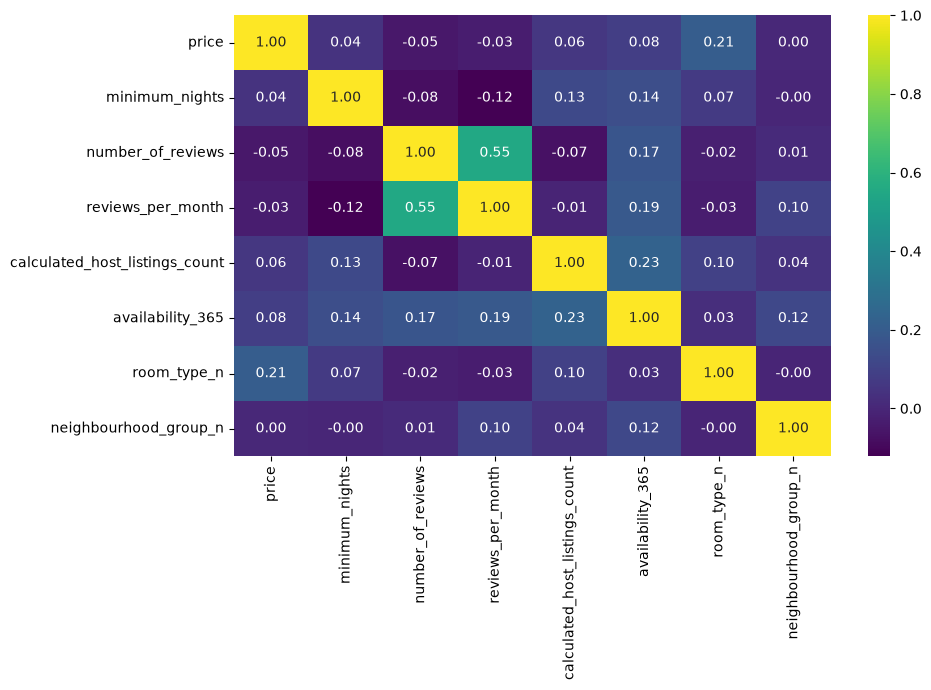

In [21]:
#con las variaables factorizadas, vuelvo a graficar incluyendolas esta vez

cols_num = ["price" , "minimum_nights" , "number_of_reviews" , "reviews_per_month" , "calculated_host_listings_count" , "availability_365", "room_type_n" , "neighbourhood_group_n"] 

fig, ax = plt.subplots(figsize=(10,7))

sns.heatmap(df[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax) #mapa calor
plt.tight_layout()
plt.show()

- Como vimos antes, parece que hay una pequeña relación entre el tipo de habitación alquilada y el precio, lo cual es bastante esperable.
- El distrito donde se ubica la vivienda no parece guardar una relación notoria con ninguna otra variable.

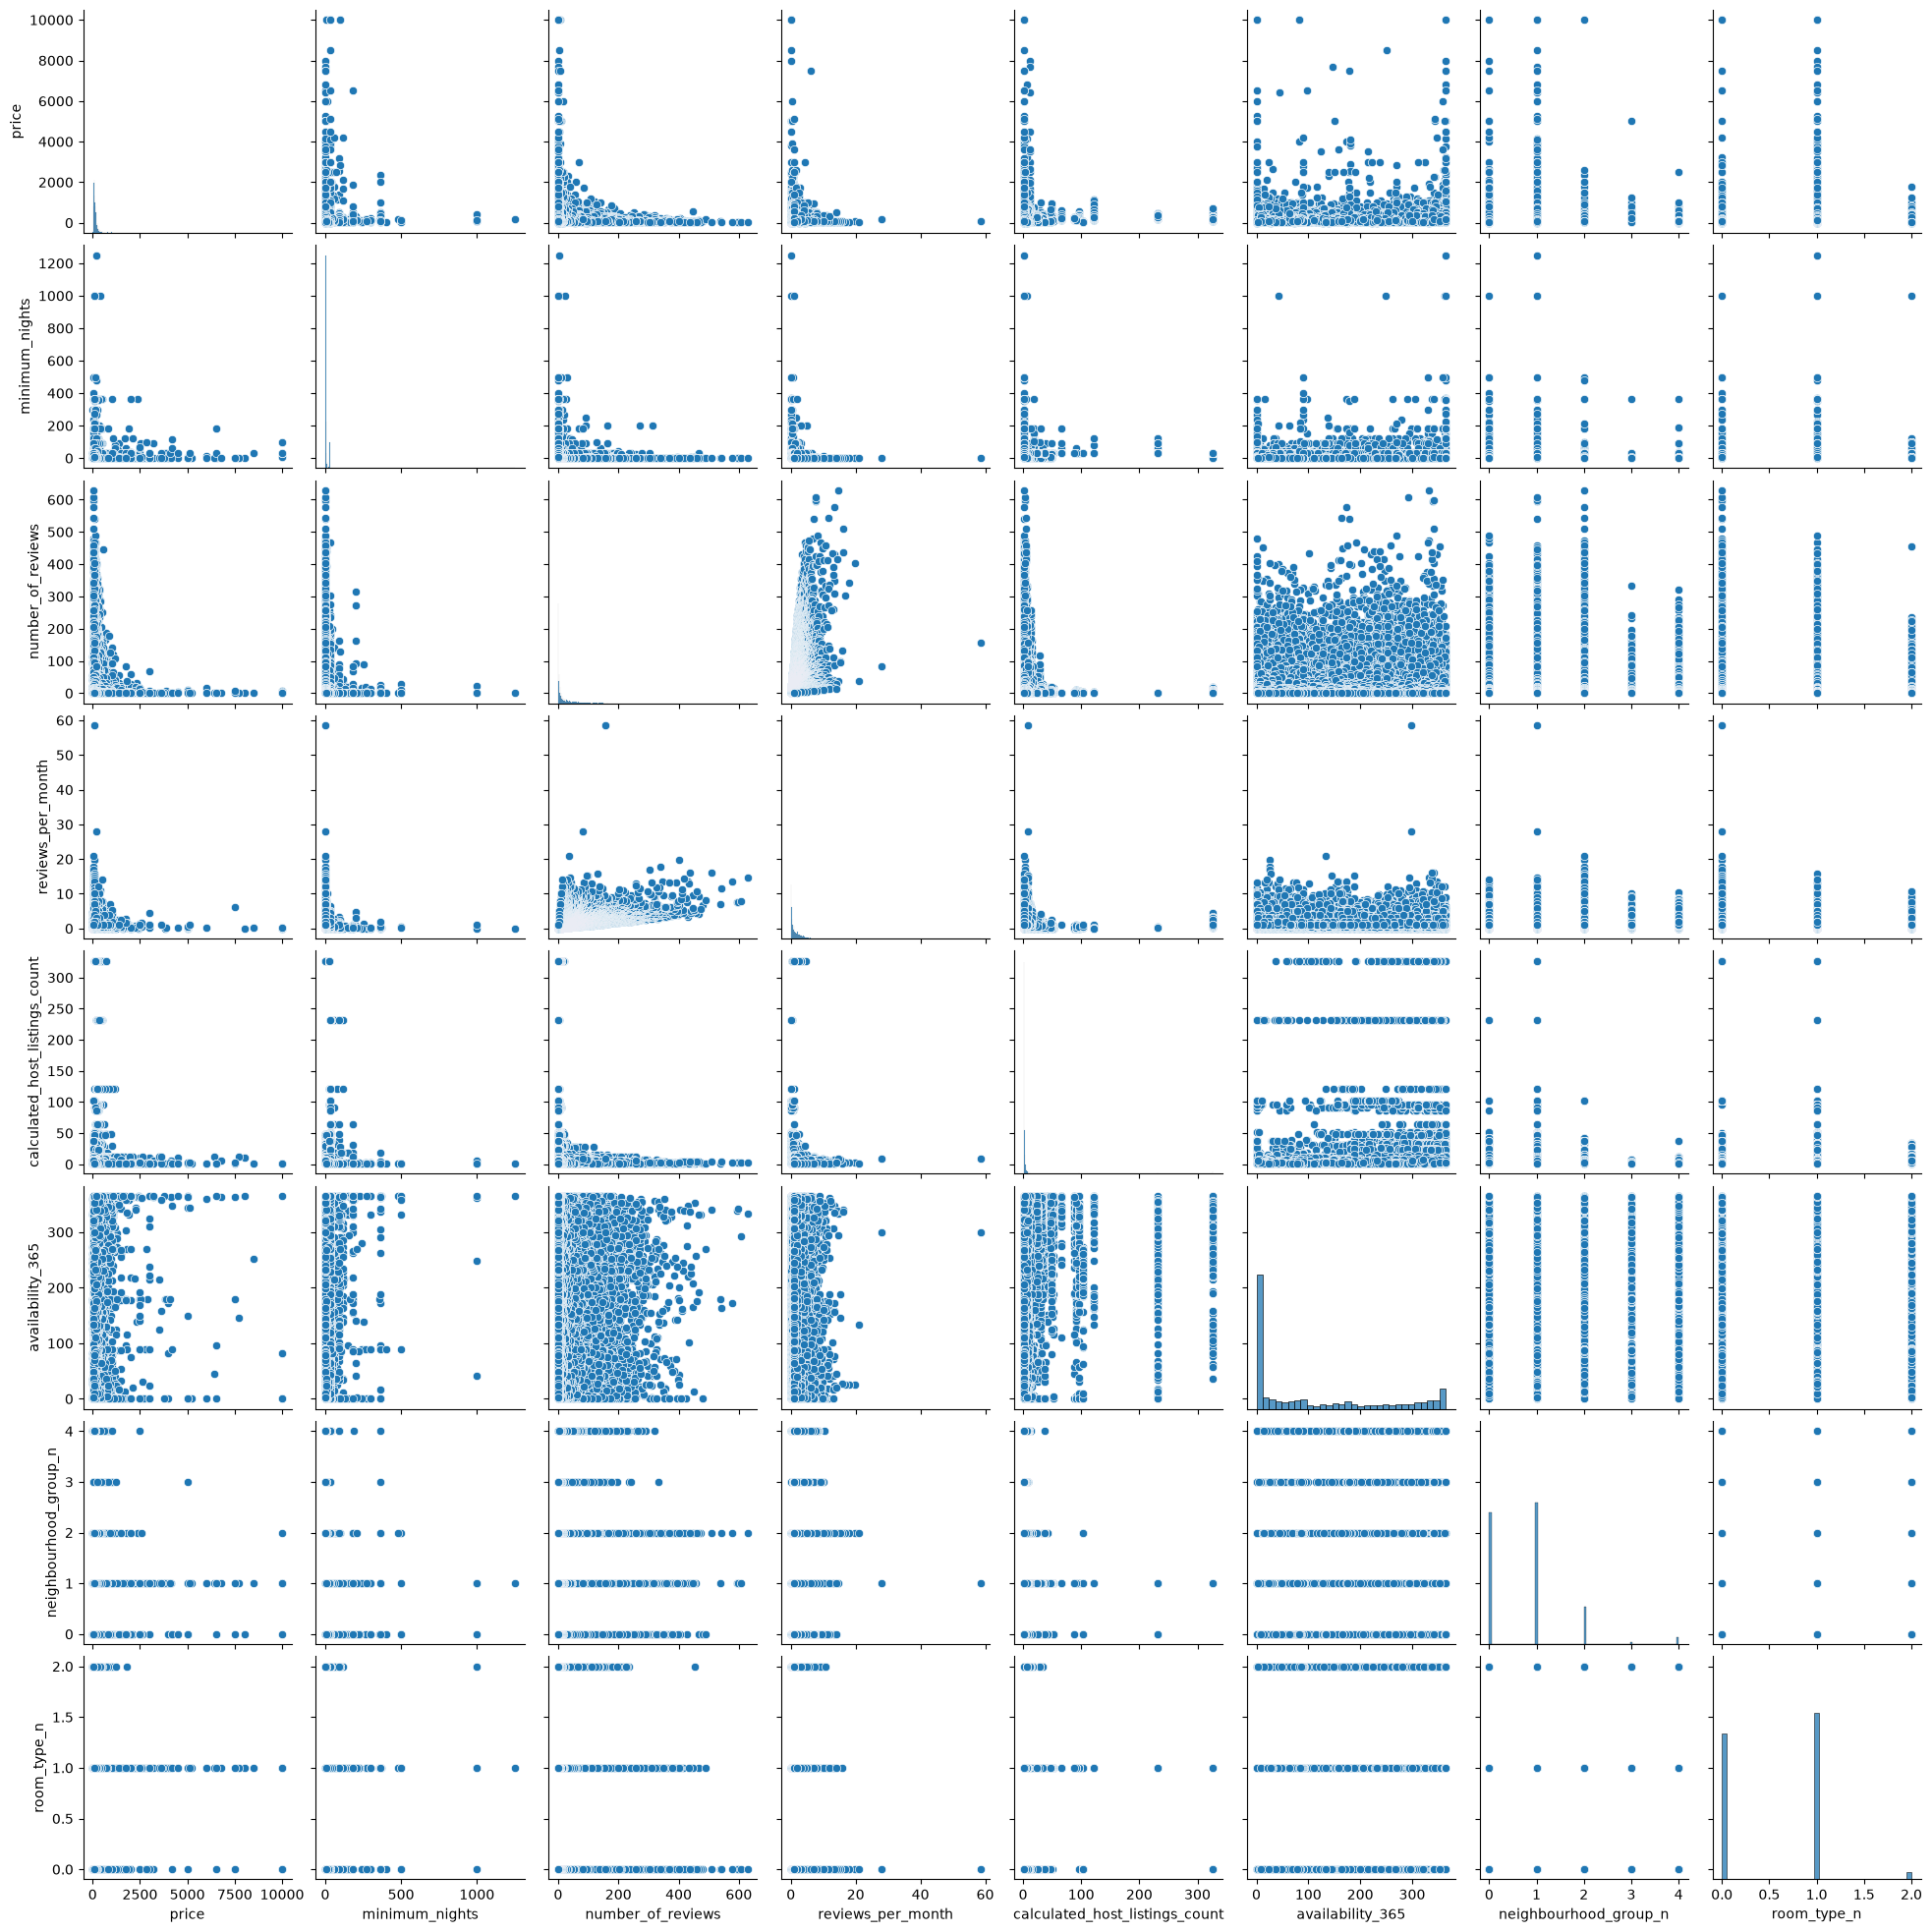

In [22]:
sns.pairplot(data = df)

## Ingeniería de características
### Outliers

In [23]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'neighbourhood_group_n', 'room_type_n'],
      dtype='str')

In [24]:
final_cols = ['price',
       'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'neighbourhood_group_n', 'room_type_n'] 

df = df[final_cols]   #dejo solo las columnas numericas que me interesan (me cargo fechas y columnas string)

In [25]:
df.columns

Index(['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'neighbourhood_group_n', 'room_type_n'],
      dtype='str')

In [26]:
df.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_n,room_type_n
count,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327,0.786911,0.567113
std,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289,0.844386,0.541249
min,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000,0.000000,0.000000
50%,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,1.000000,1.000000
75%,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000,1.000000,1.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,4.000000,2.000000


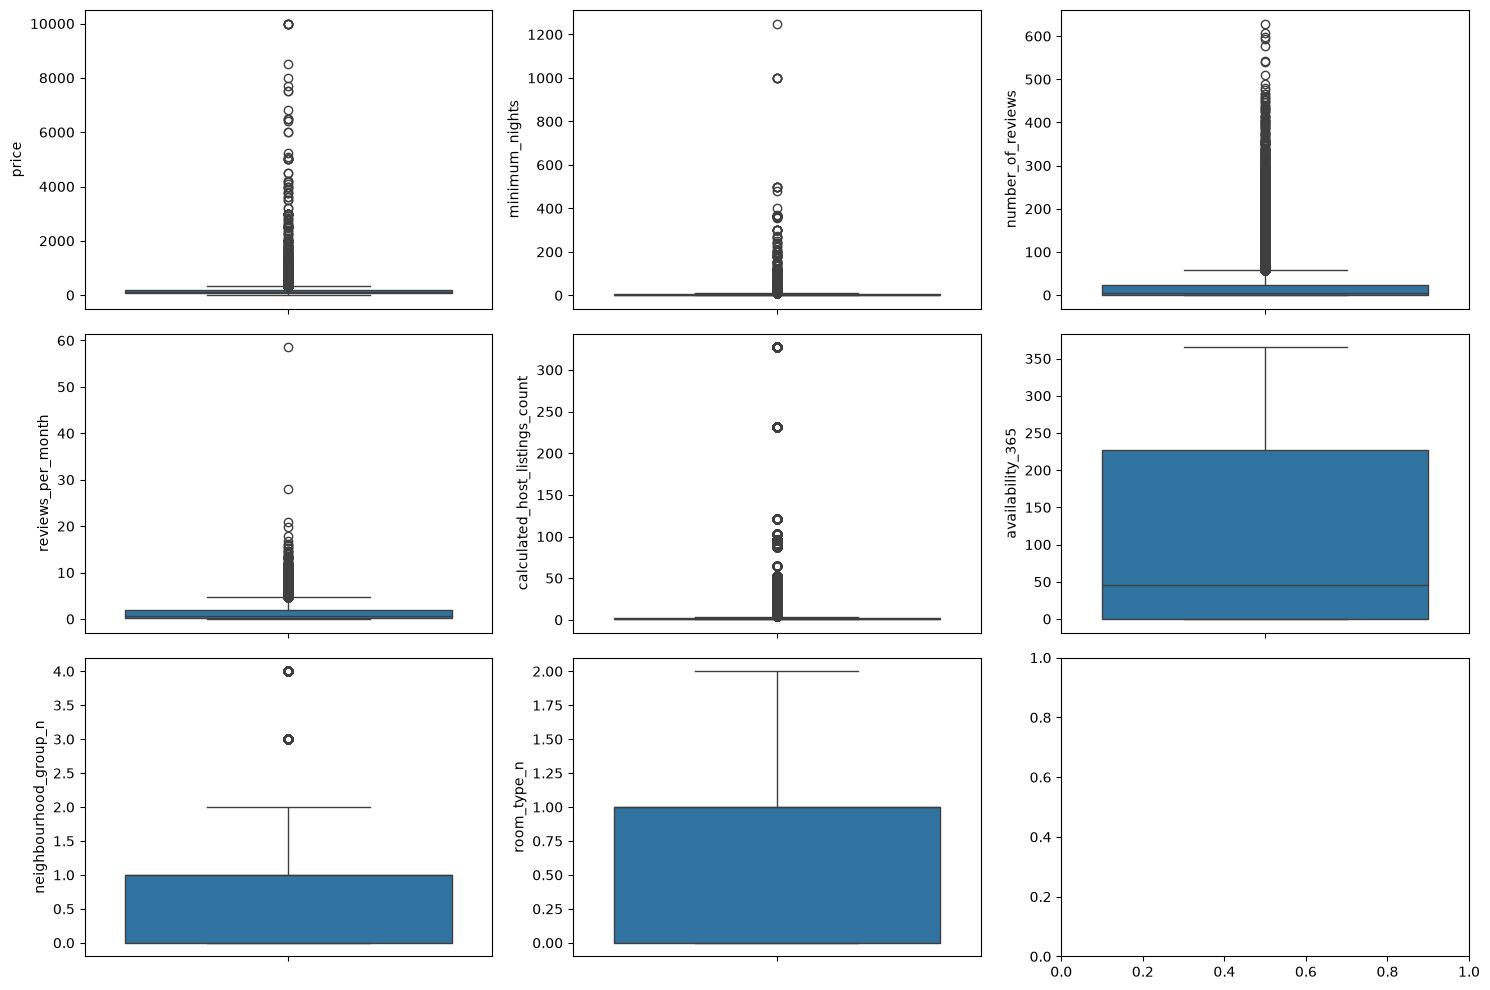

In [27]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10)) # 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'
                                                   # ['Private room', 'Entire home/apt', 'Shared room']
if "neighbourhood_group_n" not in df.columns:
    df["neighbourhood_group_n"] = df["neighbourhood_group"].map({"Brooklyn": 0, "Manhattan": 1 , "Queens" : 2 , "Staten Island" : 3, "Bronx" : 4})

if "room_type_n" not in df.columns:
    df["room_type_n"] = df["room_type"].map({"Private room": 0, "Entire home/apt": 1, "Shared room": 2})


sns.boxplot(ax = axis[0, 0], data = df, y = "price")
sns.boxplot(ax = axis[0, 1], data = df, y = "minimum_nights")
sns.boxplot(ax = axis[0, 2], data = df, y = "number_of_reviews")
sns.boxplot(ax = axis[1, 0], data = df, y = "reviews_per_month")
sns.boxplot(ax = axis[1, 1], data = df, y = "calculated_host_listings_count")
sns.boxplot(ax = axis[1, 2], data = df, y = "availability_365")
sns.boxplot(ax = axis[2, 0], data = df, y = "neighbourhood_group_n")
sns.boxplot(ax = axis[2, 1], data = df, y = "room_type_n")

plt.tight_layout()

plt.show()

Encontramos outliers en las siguientes columnas:
- Price
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- neighbourhood_group_n

In [28]:
price_stats = df.price.describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [29]:
price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(price_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de 106.0


In [30]:
df[df["price"] > 334.0] # Importes que superan el límite superior (son outliers)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_n,room_type_n
61,375,180,5,0.12,1,180,1,1
85,800,1,25,0.24,1,7,0,1
103,500,4,46,0.55,2,243,1,1
114,350,2,7,0.06,4,298,1,1
121,400,2,16,0.24,2,216,0,1
...,...,...,...,...,...,...,...,...
48758,350,2,0,NaN,1,364,2,1
48833,475,2,0,NaN,1,64,1,1
48839,800,1,0,NaN,1,23,0,0
48842,350,1,0,NaN,1,9,1,1


In [31]:
from numpy._core.defchararray import upper
# Guardar datasets

total_data_CON_outliers = df.copy()
total_data_SIN_outliers = df.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ['price' , 'minimum_nights' , 'number_of_reviews' , 'reviews_per_month' , 'calculated_host_listings_count' , 'neighbourhood_group_n']

def replace_outliers(column, dataframe): #funcion para reemplazar los outliers en la columna del df que se le pase
  col_stats = df[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(dataframe[column])
  # Quitar los outliers superiores
  dataframe[column] = dataframe[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)

  # Quitar los outliers inferiores
  dataframe[column] = dataframe[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return dataframe.copy(), [lower_limit, upper_limit]



outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'price': [0, 334.0],
 'minimum_nights': [1, 11.0],
 'number_of_reviews': [0, 58.5],
 'reviews_per_month': [0.01, 4.77],
 'calculated_host_listings_count': [1, 3.5],
 'neighbourhood_group_n': [0, 2.5]}

In [32]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

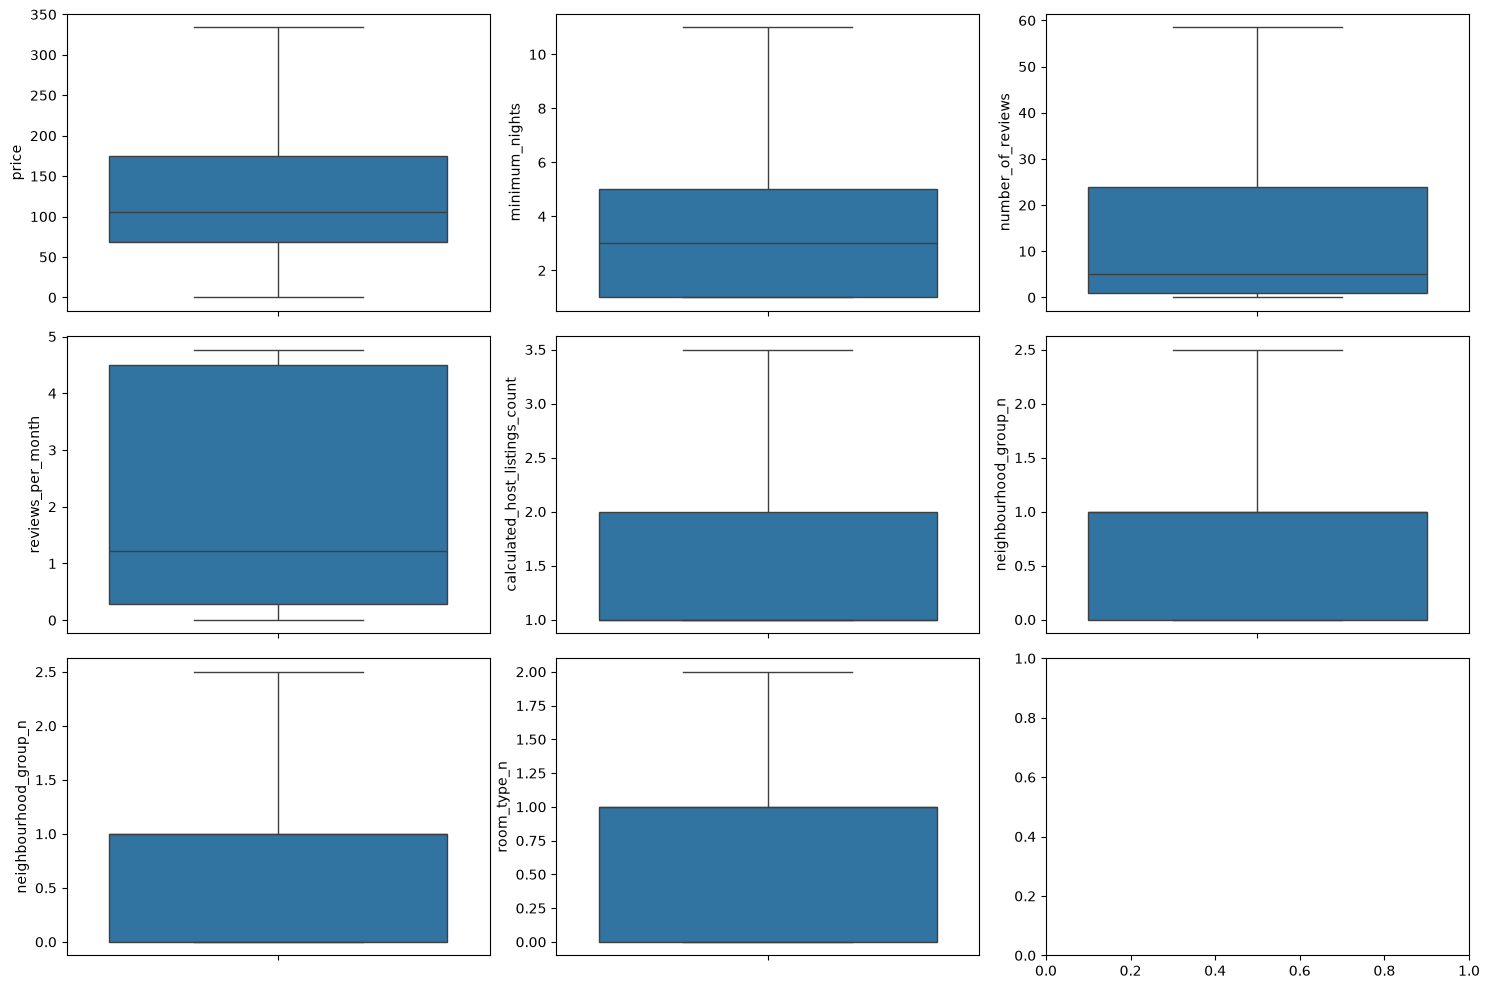

In [33]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

if "neighbourhood_group_n" not in total_data_SIN_outliers.columns:
    total_data_SIN_outliers["neighbourhood_group_n"] = total_data_SIN_outliers["neighbourhood_group"].map({"Brooklyn": 0, "Manhattan": 1 , "Queens" : 2 , "Staten Island" : 3, "Bronx" : 4})

if "room_type_n" not in total_data_SIN_outliers.columns:
    total_data_SIN_outliers["room_type_n"] = total_data_SIN_outliers["room_type"].map({"Private room": 0, "Entire home/apt": 1, "Shared room": 2})

# grafico las columnas tras cargarme los outliers

sns.boxplot(ax = axis[0, 0], data = total_data_SIN_outliers, y = "price")
sns.boxplot(ax = axis[0, 1], data = total_data_SIN_outliers, y = "minimum_nights")
sns.boxplot(ax = axis[0, 2], data = total_data_SIN_outliers, y = "number_of_reviews")
sns.boxplot(ax = axis[1, 0], data = total_data_SIN_outliers, y = "reviews_per_month")
sns.boxplot(ax = axis[1, 1], data = total_data_SIN_outliers, y = "calculated_host_listings_count")
sns.boxplot(ax = axis[1, 2], data = total_data_SIN_outliers, y = "neighbourhood_group_n")
sns.boxplot(ax = axis[2, 0], data = total_data_SIN_outliers, y = "neighbourhood_group_n")
sns.boxplot(ax = axis[2, 1], data = total_data_SIN_outliers, y = "room_type_n")

plt.tight_layout()

plt.show()

Los outliers han sido correctamente eliminados, tal como se aprecia en los gráficos.

### Análisis de valores faltantes

In [34]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

reviews_per_month                 10052
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
neighbourhood_group_n                 0
room_type_n                           0
dtype: int64

In [35]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_n             0
room_type_n                       0
dtype: int64

In [36]:
df.info() #quiero ver tipos de variables se maneja en las columnas para saber que metodo usar a continuacion del notebook de Carlos

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price                           48895 non-null  int64  
 1   minimum_nights                  48895 non-null  int64  
 2   number_of_reviews               48895 non-null  int64  
 3   reviews_per_month               38843 non-null  float64
 4   calculated_host_listings_count  48895 non-null  int64  
 5   availability_365                48895 non-null  int64  
 6   neighbourhood_group_n           48895 non-null  int64  
 7   room_type_n                     48895 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 3.0 MB


In [37]:
#reviews per month es decimal, aplico el  metodo correspondiente -> ESTA ES LA UNICA COLUMNA CON NULOS, DEJO EL RESTO COMENTADAS

total_data_CON_outliers["reviews_per_month"] = df["reviews_per_month"].fillna(df["reviews_per_month"].mean())

#ahora las categoricas, room type y neighbourhood group
#solo hay nulos en reviews per month por lo que esto es innecesario, asi que lo dejo comentado

#total_data_CON_outliers["room_type_n"] = df["room_type_n"].fillna(df["room_type_n"].mode()[0]) 
#total_data_CON_outliers["neighbourhood_group_n"] = df["neighbourhood_group_n"].fillna(df["neighbourhood_group_n"].mode()[0]) 

#imputacion numerica para price, minimum nights, number of reviews, calculated host listing count y availability 365
#solo hay nulos en reviews per month por lo que esto es innecesario, asi que lo dejo comentado

#total_data_CON_outliers["price"] = df["price"].fillna(df["price"].median())
#total_data_CON_outliers["minimum_nights"] = df["minimum_nights"].fillna(df["minimum_nights"].median())
#total_data_CON_outliers["number_of_reviews"] = df["number_of_reviews"].fillna(df["number_of_reviews"].median())
#total_data_CON_outliers["calculated_host_listings_count"] = df["calculated_host_listings_count"].fillna(df["calculated_host_listings_count"].median())
#total_data_CON_outliers["availability_365"] = df["availability_365"].fillna(df["availability_365"].median())


total_data_CON_outliers.isnull().sum()


price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_n             0
room_type_n                       0
dtype: int64

### Inferencia de nuevas características

Creo que aquí no se puede hacer nada

In [38]:
from sklearn.model_selection import train_test_split

predictoras = ['minimum_nights' , 'number_of_reviews' , 'reviews_per_month' , 'calculated_host_listings_count' , 'neighbourhood_group_n']
target = "price"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

#train se utiliza para entrenar el modelo, que aprenda sobre una region o parte de los datos
#test sirve para comprobar que el aprendizaje se ha realizado correctamente

In [39]:
#X_CON
#X_SIN
y

0        149
1        225
2        150
3         89
4         80
        ... 
48890     70
48891     40
48892    115
48893     55
48894     90
Name: price, Length: 48895, dtype: int64

### Escalado de valores

In [40]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


## NORMALIZACIÓN (cambiar valores para que tengan media de 0 y std de 1)
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN) (cambiar valores para que estén comprendidos entre 0 y 1)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)


In [41]:
X_train_CON_outliers

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,neighbourhood_group_n
13234,1,1,0.020000,4,1
45701,3,4,2.790000,1,2
6524,4,5,0.100000,1,0
33439,4,16,1.300000,7,3
24788,14,1,0.220000,1,2
...,...,...,...,...,...
40059,2,16,4.490000,1,0
28017,30,8,0.430000,91,1
29199,2,19,1.030000,4,0
40061,1,27,5.510000,1,1


In [42]:
X_train_CON_outliers_norm   #  valores con media de 0 y std de 1  (estaran entre 1 y -1)

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,neighbourhood_group_n
13234,-0.299666,-0.499573,-0.898591,-0.097713,0.252892
45701,-0.200387,-0.432582,0.945854,-0.187955,1.439143
6524,-0.150748,-0.410251,-0.845322,-0.187955,-0.933358
33439,-0.150748,-0.164614,-0.046284,-0.007470,2.625393
24788,0.345645,-0.499573,-0.765418,-0.187955,1.439143
...,...,...,...,...,...
40059,-0.250027,-0.164614,2.077825,-0.187955,-0.933358
28017,1.139875,-0.343259,-0.625587,2.519323,0.252892
29199,-0.250027,-0.097622,-0.226068,-0.097713,-0.933358
40061,-0.299666,0.081023,2.757007,-0.187955,0.252892


In [43]:
X_train_CON_outliers_scal  #valores entre 0 y 1

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,neighbourhood_group_n
13234,0.000000,0.001590,0.000171,0.009202,0.25
45701,0.001601,0.006359,0.047529,0.000000,0.50
6524,0.002402,0.007949,0.001539,0.000000,0.00
33439,0.002402,0.025437,0.022055,0.018405,0.75
24788,0.010408,0.001590,0.003590,0.000000,0.50
...,...,...,...,...,...
40059,0.000801,0.025437,0.076594,0.000000,0.00
28017,0.023219,0.012719,0.007181,0.276074,0.25
29199,0.000801,0.030207,0.017439,0.009202,0.00
40061,0.000000,0.042925,0.094033,0.000000,0.25


In [44]:
!pip install openpyxl #si no hago esto la siguiente celda me da error

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [45]:
# GUARDAR TODO 

# PATH = "/data/processed"
PATH = "."

# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
X_train_CON_outliers.to_excel(f"{PATH}/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel(f"{PATH}/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel(f"{PATH}/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel(f"{PATH}/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel(f"{PATH}/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel(f"{PATH}/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel(f"{PATH}/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel(f"{PATH}/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel(f"{PATH}/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel(f"{PATH}/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel(f"{PATH}/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel(f"{PATH}/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel(f"{PATH}/y_train.xlsx", index = False)
y_test.to_excel(f"{PATH}/y_test.xlsx", index = False)

# SCALERS
import pickle

# MODEL_PATH = "/model"
MODEL_PATH = "."

with open(f"{MODEL_PATH}/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open(f"{MODEL_PATH}/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open(f"{MODEL_PATH}/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open(f"{MODEL_PATH}/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)

In [46]:
from sklearn.feature_selection import f_classif, SelectKBest

X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

# Con un valor de k = 5 decimos implícitamente que queremos eliminar 2 características del conjunto de datos
selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,neighbourhood_group_n
0,1.0,1.0,0.02,4.0,1.0
1,3.0,4.0,2.79,1.0,2.0
2,4.0,5.0,0.10,1.0,0.0
3,4.0,16.0,1.30,7.0,3.0
4,14.0,1.0,0.22,1.0,2.0
